In [65]:
!pip install kagglehub

In [66]:
import kagglehub

path = kagglehub.dataset_download("uciml/mushroom-classification")
print("Dataset downloaded to:", path)

Using Colab cache for faster access to the 'mushroom-classification' dataset.
Dataset downloaded to: /kaggle/input/mushroom-classification


In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [68]:
import os

# Use the 'path' variable from kagglehub.dataset_download, which already points to the dataset directory
csv_file = os.path.join(path, 'mushrooms.csv')

df = pd.read_csv(csv_file)
print("Dataset loaded successfully!")
print(f"Shape: {df.shape}")
df.head()

Dataset loaded successfully!
Shape: (8124, 23)


,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


In [69]:
df.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


In [70]:
print("Dataset Information:")
print("="*50)
df.info()
print("\n" + "="*50)
print(f"Total Samples: {len(df)}")
print(f"Total Features: {df.shape[1]}")

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   class                     8124 non-null   object
 1   cap-shape                 8124 non-null   object
 2   cap-surface               8124 non-null   object
 3   cap-color                 8124 non-null   object
 4   bruises                   8124 non-null   object
 5   odor                      8124 non-null   object
 6   gill-attachment           8124 non-null   object
 7   gill-spacing              8124 non-null   object
 8   gill-size                 8124 non-null   object
 9   gill-color                8124 non-null   object
 10  stalk-shape               8124 non-null   object
 11  stalk-root                8124 non-null   object
 12  stalk-surface-above-ring  8124 non-null   object
 13  stalk-surface-below-ring  8124 non-null   object
 14  sta

In [71]:
print("Missing Values Check:")
print("="*50)
missing = df.isnull().sum()
print(missing)
print("\n" + "="*50)
print(f"Total Missing Values: {missing.sum()}")

Missing Values Check:
class                       0
cap-shape                   0
cap-surface                 0
cap-color                   0
bruises                     0
odor                        0
gill-attachment             0
gill-spacing                0
gill-size                   0
gill-color                  0
stalk-shape                 0
stalk-root                  0
stalk-surface-above-ring    0
stalk-surface-below-ring    0
stalk-color-above-ring      0
stalk-color-below-ring      0
veil-type                   0
veil-color                  0
ring-number                 0
ring-type                   0
spore-print-color           0
population                  0
habitat                     0
dtype: int64

Total Missing Values: 0


In [72]:
print("Target Class Distribution:")
print("="*50)
print(df['class'].value_counts())
print("\n" + "="*50)
print(df['class'].value_counts(normalize=True) * 100)

Target Class Distribution:
class
e    4208
p    3916
Name: count, dtype: int64

class
e    51.797144
p    48.202856
Name: proportion, dtype: float64


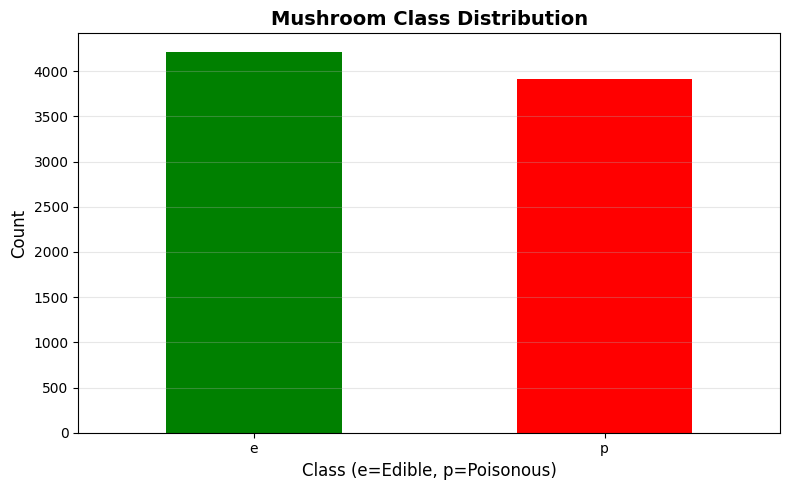

In [73]:
plt.figure(figsize=(8, 5))
df['class'].value_counts().plot(kind='bar', color=['green', 'red'])
plt.title('Mushroom Class Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Class (e=Edible, p=Poisonous)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [74]:
X = df.drop('class', axis=1)
y = df['class']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nTarget distribution:\n{y.value_counts()}")

Features shape: (8124, 22)
Target shape: (8124,)

Target distribution:
class
e    4208
p    3916
Name: count, dtype: int64


In [75]:
print("Unique Values in Each Feature:")
print("="*50)
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")

Unique Values in Each Feature:
class: 2 unique values
cap-shape: 6 unique values
cap-surface: 4 unique values
cap-color: 10 unique values
bruises: 2 unique values
odor: 9 unique values
gill-attachment: 2 unique values
gill-spacing: 2 unique values
gill-size: 2 unique values
gill-color: 12 unique values
stalk-shape: 2 unique values
stalk-root: 5 unique values
stalk-surface-above-ring: 4 unique values
stalk-surface-below-ring: 4 unique values
stalk-color-above-ring: 9 unique values
stalk-color-below-ring: 9 unique values
veil-type: 1 unique values
veil-color: 4 unique values
ring-number: 3 unique values
ring-type: 5 unique values
spore-print-color: 9 unique values
population: 6 unique values
habitat: 7 unique values


In [76]:
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
import pandas as pd

# Define features (X) and target (y)
X = df.drop('class', axis=1)
y = df['class']

X_encoded = pd.get_dummies(X, drop_first=True)

# Encode the target variable 'y'
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("Features encoded successfully using One-Hot Encoding!")
print(f"Encoded features shape: {X_encoded.shape}")
print(f"Original features: {X.shape[1]}")
print(f"After One-Hot Encoding: {X_encoded.shape[1]}")
print("\nFirst 5 rows of encoded features:")
print(X_encoded.head())
print("\nTarget encoded successfully!")
print(f"Original target: {y[:5].values}")
print(f"Encoded target: {y_encoded[:5]}")
print(f"\nEncoding mapping: e={le.transform(['e'])[0]}, p={le.transform(['p'])[0]}")

Features encoded successfully using One-Hot Encoding!
Encoded features shape: (8124, 95)
Original features: 22
After One-Hot Encoding: 95

First 5 rows of encoded features:
   cap-shape_c  cap-shape_f  cap-shape_k  cap-shape_s  cap-shape_x  \
0        False        False        False        False         True   
1        False        False        False        False         True   
2        False        False        False        False        False   
3        False        False        False        False         True   
4        False        False        False        False         True   

   cap-surface_g  cap-surface_s  cap-surface_y  cap-color_c  cap-color_e  ...  \
0          False           True          False        False        False  ...   
1          False           True          False        False        False  ...   
2          False           True          False        False        False  ...   
3          False          False           True        False        False  ...   
4

In [77]:
y_encoded = le.fit_transform(y)

print("Target encoded successfully!")
print(f"Original target: {y[:5].values}")
print(f"Encoded target: {y_encoded[:5]}")
print(f"\nEncoding mapping: e={le.transform(['e'])[0]}, p={le.transform(['p'])[0]}")

Target encoded successfully!
Original target: ['p' 'e' 'e' 'p' 'e']
Encoded target: [1 0 0 1 0]

Encoding mapping: e=0, p=1


Using Colab cache for faster access to the 'mushroom-classification' dataset.
Top 10 Features by Gini Importance:
stalk-surface-above-ring_k    0.149605
spore-print-color_h           0.131559
spore-print-color_n           0.129837
odor_n                        0.122299
odor_f                        0.112563
gill-spacing_w                0.084205
ring-type_p                   0.077701
odor_y                        0.068332
ring-number_t                 0.067573
spore-print-color_w           0.047949
dtype: float64


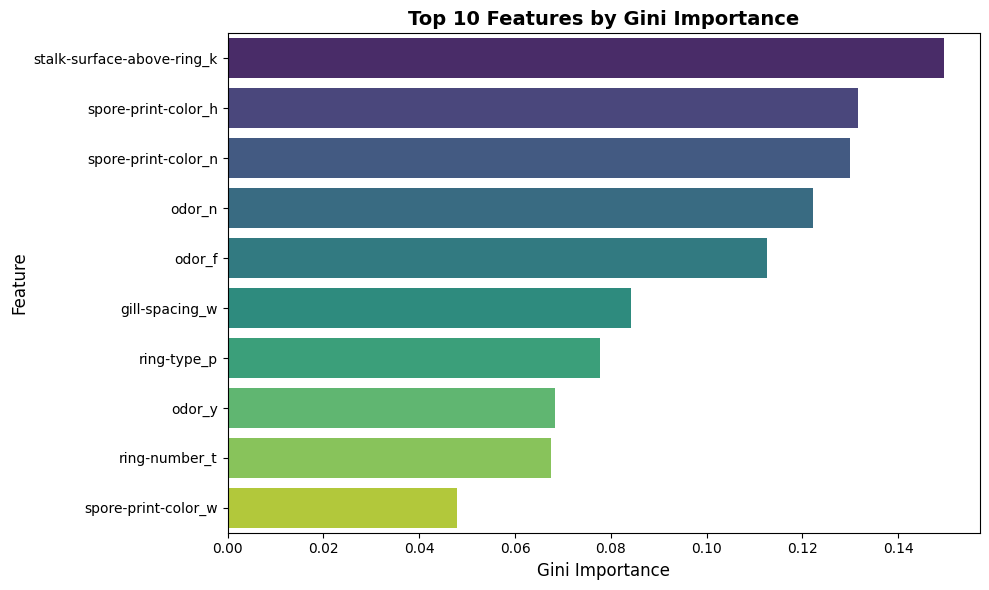

In [78]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
import kagglehub
import os

# --- Load Dataset and Define df ---
# This ensures 'df' is available even if previous data loading cells were not run.
path = kagglehub.dataset_download("uciml/mushroom-classification")
csv_file = os.path.join(path, 'mushrooms.csv')
df = pd.read_csv(csv_file)

# --- Re-creating dependencies for rf_tuned ---
# 1. Define features (X) and target (y) and encode them
X = df.drop('class', axis=1)
y = df['class']

X_encoded = pd.get_dummies(X, drop_first=True)

le = LabelEncoder()
y_encoded = le.fit_transform(y)

# 2. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y_encoded, test_size=0.2, random_state=42)

# 3. Random Forest Hyperparameter Tuning to define rf_tuned
rf_params = {
    'n_estimators': [3, 5],
    'max_depth': [2, 3],
    'min_samples_split': [80, 100],
    'min_samples_leaf': [40, 50],
    'max_features': [3, 5]
}
rf_model = RandomForestClassifier(random_state=42)
rf_grid = GridSearchCV(rf_model, rf_params, cv=3, scoring='accuracy', n_jobs=-1)
rf_grid.fit(X_train, y_train)
rf_tuned = rf_grid.best_estimator_

# --- Original code to display top 10 features ---
feature_importances = pd.Series(rf_tuned.feature_importances_, index=X_encoded.columns)
top_10_features = feature_importances.nlargest(10)

print("Top 10 Features by Gini Importance:")
print("="*50)
print(top_10_features)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_10_features.values, y=top_10_features.index, palette='viridis', hue=top_10_features.index, legend=False)
plt.title('Top 10 Features by Gini Importance', fontsize=14, fontweight='bold')
plt.xlabel('Gini Importance', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.tight_layout()
plt.show()

Top 10 Features by Permutation Importance:
odor_n                        0.073354
spore-print-color_h           0.030523
spore-print-color_n           0.009723
ring-type_p                   0.009477
spore-print-color_w           0.005785
gill-spacing_w                0.005662
stalk-surface-above-ring_k    0.004923
ring-number_t                 0.002215
odor_y                        0.000985
odor_f                        0.000369
dtype: float64


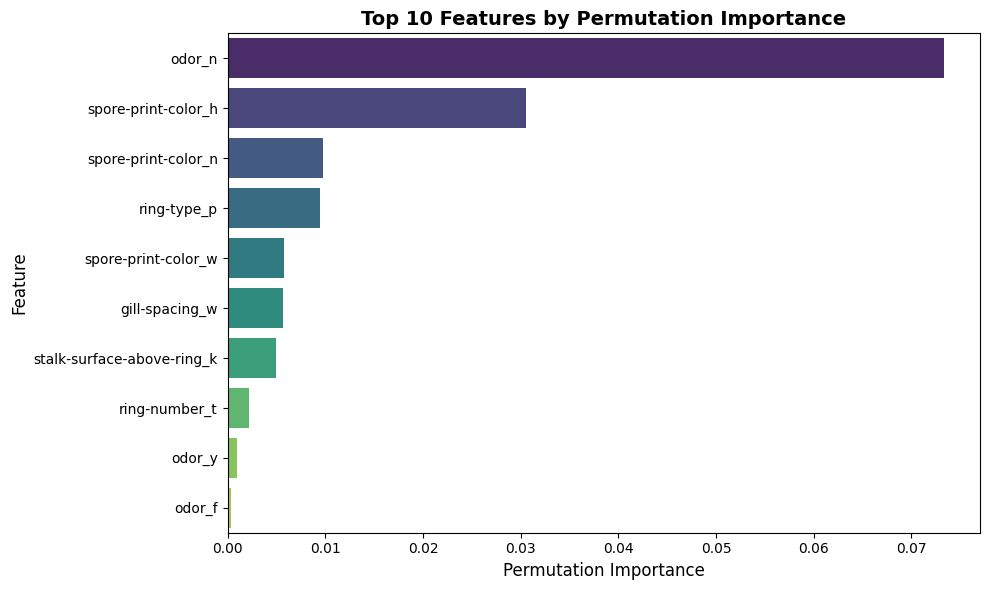

In [79]:
!pip install eli5
import eli5
from eli5.sklearn import PermutationImportance
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate permutation importance
perm = PermutationImportance(rf_tuned, random_state=42).fit(X_test, y_test)

# Store importances in a pandas Series
permutation_importances = pd.Series(perm.feature_importances_, index=X_test.columns)

# Get top 10 features by permutation importance
top_10_perm_features = permutation_importances.nlargest(10)

print("Top 10 Features by Permutation Importance:")
print("="*50)
print(top_10_perm_features)

# Plotting the top 10 features
plt.figure(figsize=(10, 6))
sns.barplot(x=top_10_perm_features.values, y=top_10_perm_features.index, palette='viridis', hue=top_10_perm_features.index, legend=False)
plt.title('Top 10 Features by Permutation Importance', fontsize=14, fontweight='bold')
plt.xlabel('Permutation Importance', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.tight_layout()
plt.show()

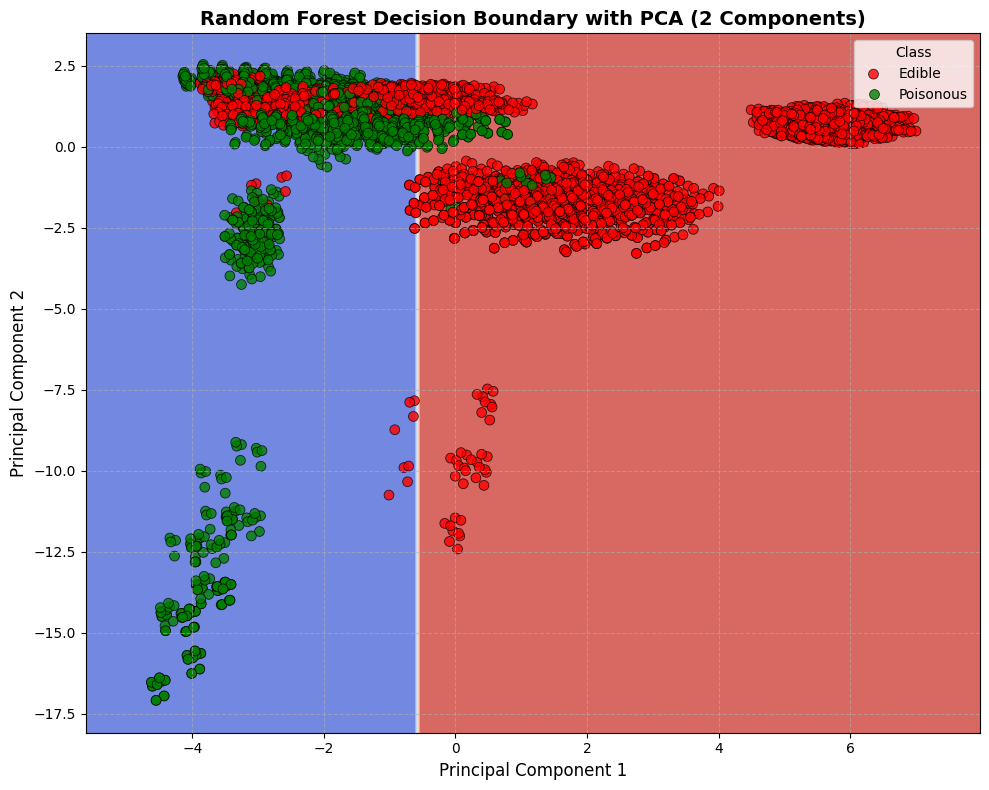

In [92]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import numpy as np

# Scale the features before applying PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_encoded)

# Apply PCA to reduce to 2 components for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Split the PCA-transformed data
X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(X_pca, y_encoded, test_size=0.2, random_state=42)

# Train a classifier on the PCA-transformed training data
# Using the best estimator from the previous tuning (rf_tuned) for consistency
rf_pca = RandomForestClassifier(n_estimators=rf_tuned.n_estimators,
                                max_depth=rf_tuned.max_depth,
                                min_samples_split=rf_tuned.min_samples_split,
                                min_samples_leaf=rf_tuned.min_samples_leaf,
                                max_features=rf_tuned.max_features,
                                random_state=42)
rf_pca.fit(X_train_pca, y_train_pca)

# Create a meshgrid for plotting the decision boundary
x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                     np.arange(y_min, y_max, 0.1))

# Predict the class for each point in the meshgrid
Z = rf_pca.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot the decision boundary
plt.figure(figsize=(10, 8))
plt.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.coolwarm)

# Plot the training points
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y_encoded,
                palette=['green', 'red'], s=50, alpha=0.8, edgecolor='k')

plt.title('Random Forest Decision Boundary with PCA (2 Components)', fontsize=14, fontweight='bold')
plt.xlabel('Principal Component 1', fontsize=12)
plt.ylabel('Principal Component 2', fontsize=12)
plt.legend(title='Class', loc='upper right', labels=['Edible', 'Poisonous'])
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

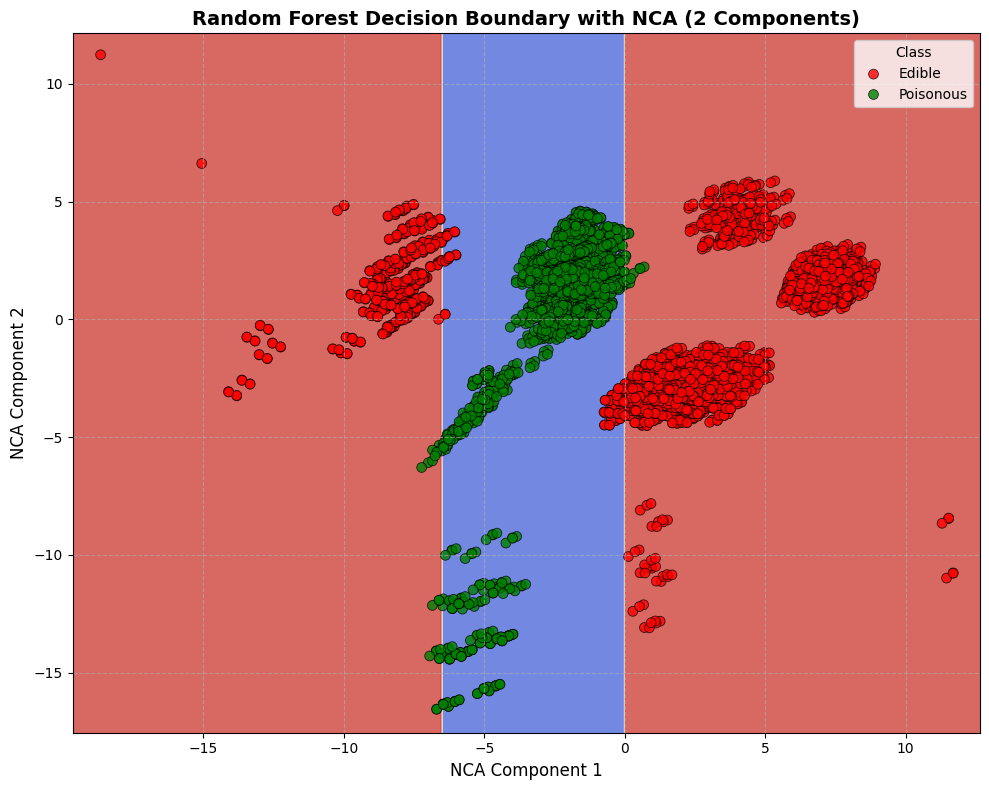

In [93]:
from sklearn.neighbors import NeighborhoodComponentsAnalysis
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# Scale the features before applying NCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_encoded)

# Apply NCA to reduce to 2 components for visualization
nca = NeighborhoodComponentsAnalysis(n_components=2, random_state=42)
X_nca = nca.fit_transform(X_scaled, y_encoded)

# Split the NCA-transformed data
X_train_nca, X_test_nca, y_train_nca, y_test_nca = train_test_split(X_nca, y_encoded, test_size=0.2, random_state=42)

# Train a classifier on the NCA-transformed training data
# Using the best estimator from the previous tuning (rf_tuned) for consistency
rf_nca = RandomForestClassifier(n_estimators=rf_tuned.n_estimators,
                                max_depth=rf_tuned.max_depth,
                                min_samples_split=rf_tuned.min_samples_split,
                                min_samples_leaf=rf_tuned.min_samples_leaf,
                                max_features=rf_tuned.max_features,
                                random_state=42)
rf_nca.fit(X_train_nca, y_train_nca)

# Create a meshgrid for plotting the decision boundary
x_min, x_max = X_nca[:, 0].min() - 1, X_nca[:, 0].max() + 1
y_min, y_max = X_nca[:, 1].min() - 1, X_nca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                     np.arange(y_min, y_max, 0.1))

# Predict the class for each point in the meshgrid
Z = rf_nca.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot the decision boundary
plt.figure(figsize=(10, 8))
plt.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.coolwarm)

# Plot the training points
sns.scatterplot(x=X_nca[:, 0], y=X_nca[:, 1], hue=y_encoded,
                palette=['green', 'red'], s=50, alpha=0.8, edgecolor='k')

plt.title('Random Forest Decision Boundary with NCA (2 Components)', fontsize=14, fontweight='bold')
plt.xlabel('NCA Component 1', fontsize=12)
plt.ylabel('NCA Component 2', fontsize=12)
plt.legend(title='Class', loc='upper right', labels=['Edible', 'Poisonous'])
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [80]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_encoded, y_encoded, test_size=0.2, random_state=42)

print("Train-Test Split Completed!")
print("="*50)
print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")
print(f"\nTraining features shape: {X_train.shape}")
print(f"Testing features shape: {X_test.shape}")
print(f"Training target shape: {y_train.shape}")
print(f"Testing target shape: {y_test.shape}")

Train-Test Split Completed!
Training set size: 6499 samples
Testing set size: 1625 samples

Training features shape: (6499, 95)
Testing features shape: (1625, 95)
Training target shape: (6499,)
Testing target shape: (1625,)


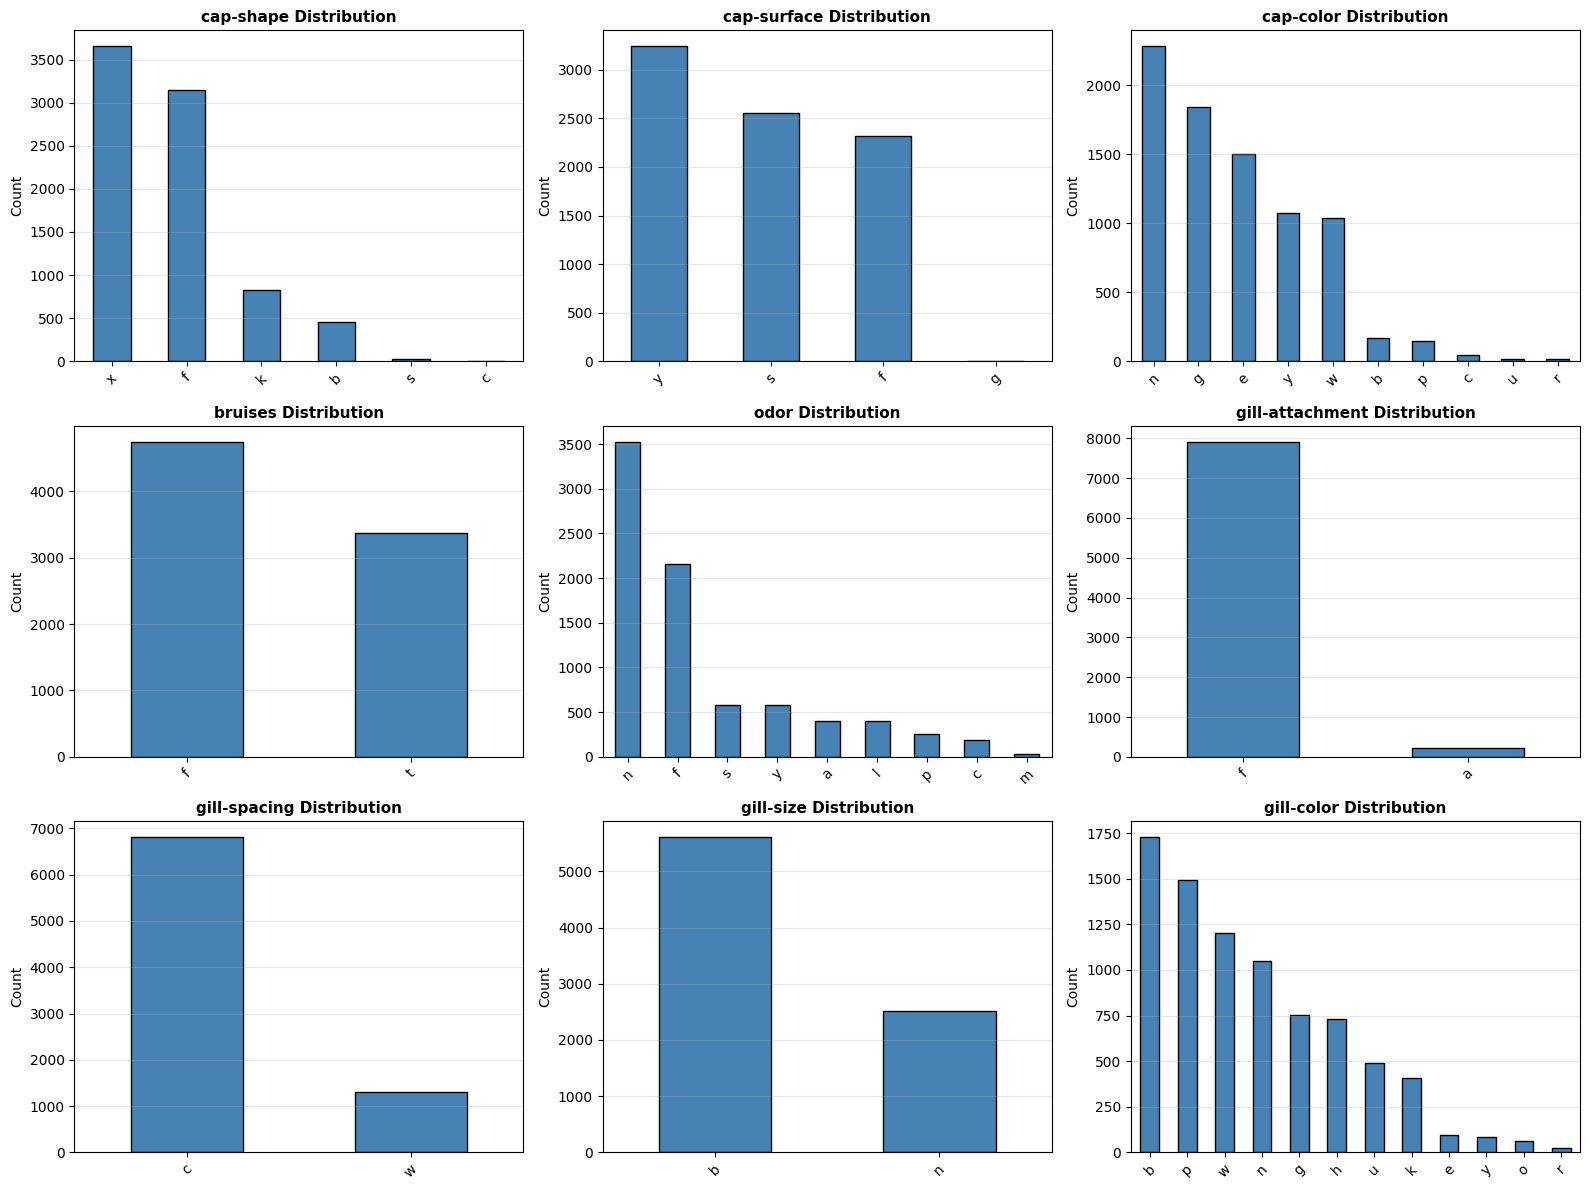

In [89]:
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.ravel()

categorical_features = ['cap-shape', 'cap-surface', 'cap-color', 'bruises', 'odor',
                        'gill-attachment', 'gill-spacing', 'gill-size', 'gill-color']

for idx, feature in enumerate(categorical_features):
    df[feature].value_counts().plot(kind='bar', ax=axes[idx], color='steelblue', edgecolor='black')
    axes[idx].set_title(f'{feature} Distribution', fontsize=11, fontweight='bold')
    axes[idx].set_xlabel('')
    axes[idx].set_ylabel('Count', fontsize=10)
    axes[idx].tick_params(axis='x', rotation=45)
    axes[idx].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [94]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import roc_curve, auc, precision_recall_curve, roc_auc_score
from sklearn.metrics import precision_score, recall_score, f1_score

print("Model libraries imported successfully!")

Model libraries imported successfully!


In [95]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import roc_curve, auc, precision_recall_curve, roc_auc_score
from sklearn.metrics import precision_score, recall_score, f1_score

print("Model libraries imported successfully!")

Model libraries imported successfully!


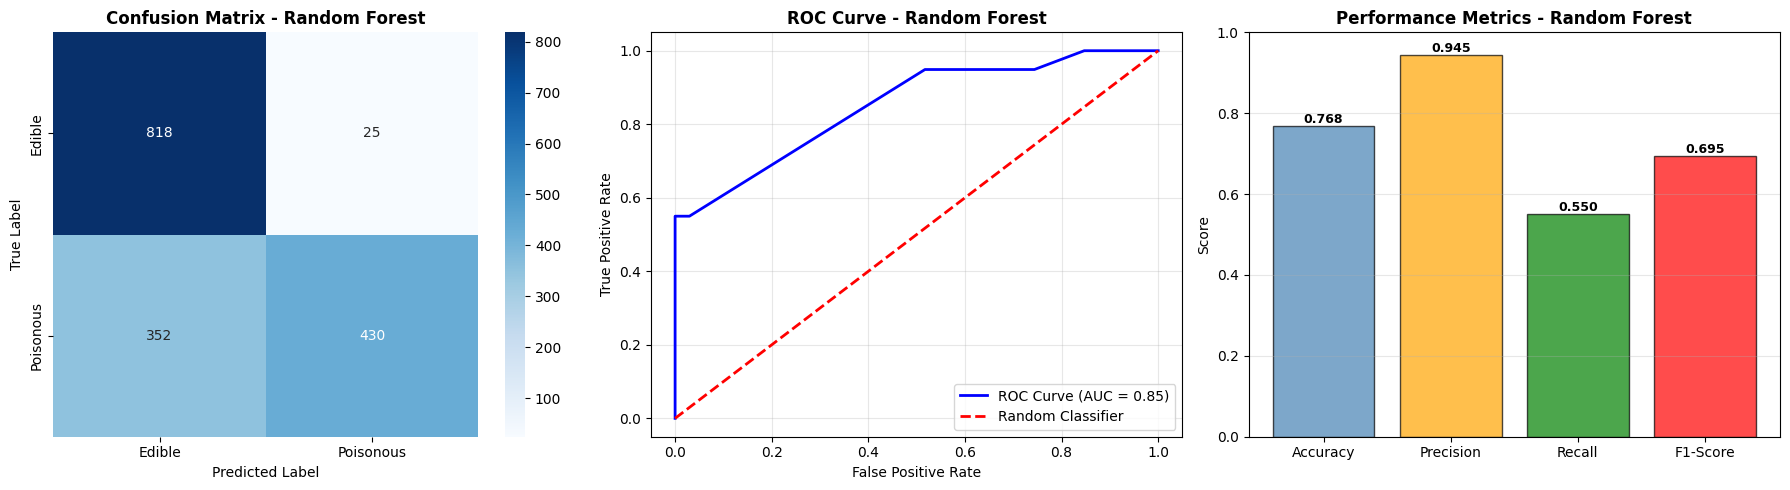

In [85]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

cm_rf = confusion_matrix(y_test, rf_raw_pred)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', cbar=True,
            xticklabels=['Edible', 'Poisonous'],
            yticklabels=['Edible', 'Poisonous'], ax=axes[0])
axes[0].set_title('Confusion Matrix - Random Forest', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicted Label', fontsize=10)
axes[0].set_ylabel('True Label', fontsize=10)

fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_raw_pred_proba)
roc_auc_rf = auc(fpr_rf, tpr_rf)
axes[1].plot(fpr_rf, tpr_rf, color='blue', lw=2, label=f'ROC Curve (AUC = {roc_auc_rf:.2f})')
axes[1].plot([0, 1], [0, 1], color='red', lw=2, linestyle='--', label='Random Classifier')
axes[1].set_xlabel('False Positive Rate', fontsize=10)
axes[1].set_ylabel('True Positive Rate', fontsize=10)
axes[1].set_title('ROC Curve - Random Forest', fontsize=12, fontweight='bold')
axes[1].legend(loc='lower right')
axes[1].grid(alpha=0.3)

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
values = [rf_raw_accuracy, rf_raw_precision, rf_raw_recall, rf_raw_f1]
bars = axes[2].bar(metrics, values, color=['steelblue', 'orange', 'green', 'red'], alpha=0.7, edgecolor='black')
axes[2].set_ylim(0, 1)
axes[2].set_ylabel('Score', fontsize=10)
axes[2].set_title('Performance Metrics - Random Forest', fontsize=12, fontweight='bold')
axes[2].grid(axis='y', alpha=0.3)
for bar in bars:
    height = bar.get_height()
    axes[2].text(bar.get_x() + bar.get_width()/2., height,
                 f'{height:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

In [86]:
from sklearn.model_selection import GridSearchCV

print("Training Random Forest with Hyperparameter Tuning...")
print("="*60)

rf_params = {
    'n_estimators': [3, 5],
    'max_depth': [2, 3],
    'min_samples_split': [80, 100],
    'min_samples_leaf': [40, 50],
    'max_features': [3, 5]
}

rf_model = RandomForestClassifier(random_state=42)
rf_grid = GridSearchCV(rf_model, rf_params, cv=3, scoring='accuracy', n_jobs=-1)
rf_grid.fit(X_train, y_train)

rf_tuned = rf_grid.best_estimator_
rf_tuned_pred = rf_tuned.predict(X_test)
rf_tuned_pred_proba = rf_tuned.predict_proba(X_test)[:, 1]

rf_tuned_accuracy = accuracy_score(y_test, rf_tuned_pred)
rf_tuned_precision = precision_score(y_test, rf_tuned_pred)
rf_tuned_recall = recall_score(y_test, rf_tuned_pred)
rf_tuned_f1 = f1_score(y_test, rf_tuned_pred)

print(f"Best Parameters: {rf_grid.best_params_}")
print(f"\nRandom Forest Tuned Model Accuracy: {rf_tuned_accuracy:.4f} ({rf_tuned_accuracy * 100:.2f}%)")
print(f"Precision: {rf_tuned_precision:.4f}")
print(f"Recall: {rf_tuned_recall:.4f}")
print(f"F1-Score: {rf_tuned_f1:.4f}")
print("\n" + "="*60)
print("Classification Report:")
print("="*60)
print(classification_report(y_test, rf_tuned_pred, target_names=['Edible', 'Poisonous']))

Training Random Forest with Hyperparameter Tuning...
Best Parameters: {'max_depth': 2, 'max_features': 5, 'min_samples_leaf': 40, 'min_samples_split': 80, 'n_estimators': 5}

Random Forest Tuned Model Accuracy: 0.9268 (92.68%)
Precision: 1.0000
Recall: 0.8478
F1-Score: 0.9176

Classification Report:
              precision    recall  f1-score   support

      Edible       0.88      1.00      0.93       843
   Poisonous       1.00      0.85      0.92       782

    accuracy                           0.93      1625
   macro avg       0.94      0.92      0.93      1625
weighted avg       0.94      0.93      0.93      1625



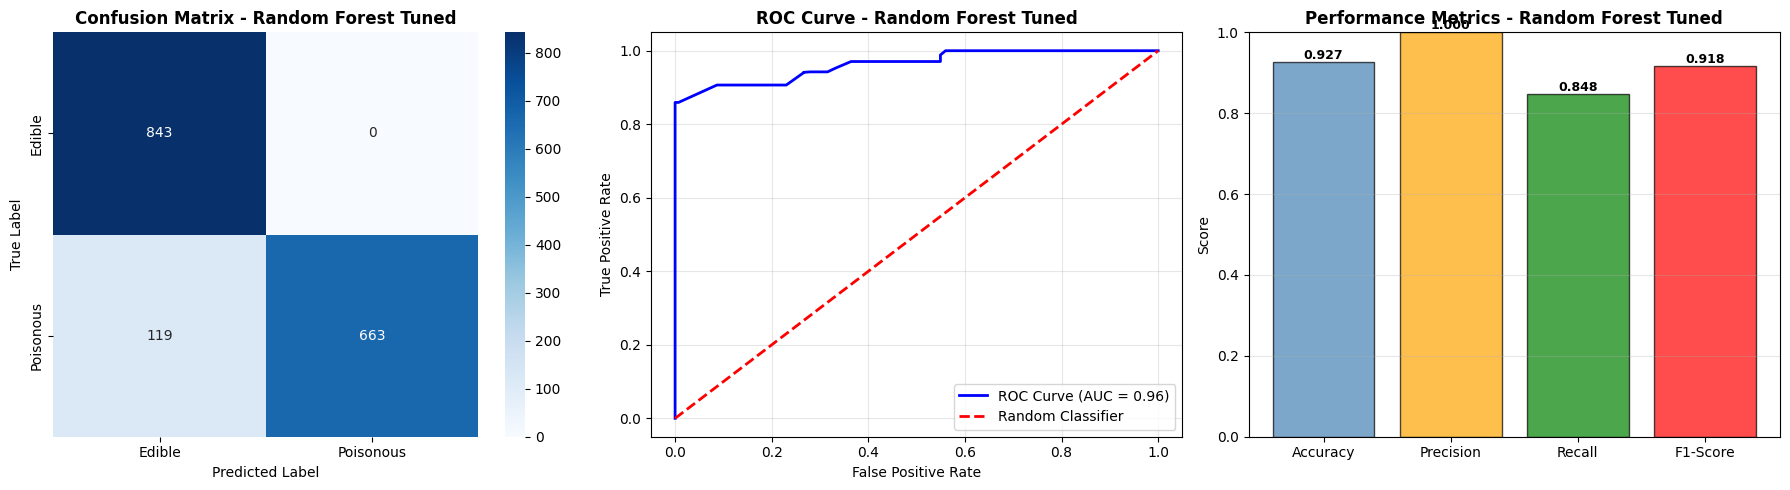

In [87]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

cm_rf_tuned = confusion_matrix(y_test, rf_tuned_pred)
sns.heatmap(cm_rf_tuned, annot=True, fmt='d', cmap='Blues', cbar=True,
            xticklabels=['Edible', 'Poisonous'],
            yticklabels=['Edible', 'Poisonous'], ax=axes[0])
axes[0].set_title('Confusion Matrix - Random Forest Tuned', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicted Label', fontsize=10)
axes[0].set_ylabel('True Label', fontsize=10)

fpr_rf_tuned, tpr_rf_tuned, _ = roc_curve(y_test, rf_tuned_pred_proba)
roc_auc_rf_tuned = auc(fpr_rf_tuned, tpr_rf_tuned)
axes[1].plot(fpr_rf_tuned, tpr_rf_tuned, color='blue', lw=2, label=f'ROC Curve (AUC = {roc_auc_rf_tuned:.2f})')
axes[1].plot([0, 1], [0, 1], color='red', lw=2, linestyle='--', label='Random Classifier')
axes[1].set_xlabel('False Positive Rate', fontsize=10)
axes[1].set_ylabel('True Positive Rate', fontsize=10)
axes[1].set_title('ROC Curve - Random Forest Tuned', fontsize=12, fontweight='bold')
axes[1].legend(loc='lower right')
axes[1].grid(alpha=0.3)

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
values = [rf_tuned_accuracy, rf_tuned_precision, rf_tuned_recall, rf_tuned_f1]
bars = axes[2].bar(metrics, values, color=['steelblue', 'orange', 'green', 'red'], alpha=0.7, edgecolor='black')
axes[2].set_ylim(0, 1)
axes[2].set_ylabel('Score', fontsize=10)
axes[2].set_title('Performance Metrics - Random Forest Tuned', fontsize=12, fontweight='bold')
axes[2].grid(axis='y', alpha=0.3)
for bar in bars:
    height = bar.get_height()
    axes[2].text(bar.get_x() + bar.get_width()/2., height,
                 f'{height:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()